# __Модель детекции ботов__

#### __1. Данные__

__Считаем данные:__

In [1]:
import numpy as np
import pandas as pd

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


In [2]:
train.head(3)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0


In [3]:
events.head(3)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0


__Работа с данными__

In [4]:
train.isna().sum()

cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
target               0
dtype: int64

In [5]:
events.event_name.value_counts()


event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64

In [6]:
events.platform.value_counts()

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

__Доля пропусков по колонкам:__

In [6]:
events.isna().mean().round(3)

cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64

__Дубликаты__:

In [7]:
events.duplicated().sum()

4863

In [8]:
events[events.duplicated(keep=False)].sort_values(["cookie_id", "event_ts"]).head(6)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN


__Большое количество дубликатов объясняется значениями NaN во многих колонках при совпадении значений в остальных колонках, удалять дубликаты не будем.__

__Оставляем события внутри временного окна:__

In [9]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

198436 89690


#### __2. Baseline-модель__

В качестве признаков базовой модели возьмём: 
1) количество событий *n_events*,
2) количество уникальных eid *n_unique_eid*,
3) количество уникальных item_id *n_unique_items*, 
4) количество уникальных item_category *n_unique_categories*, 
5) *eid_per_event = n_unique_eid/n_events*,
6) *items_per_event = n_unique_items/n_events*, 
7) количество событий в секунду *events_per_sec*.

In [10]:
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame()
    f['n_events']= g.size()
    f["n_unique_eid"]= g["eid"].nunique()
    f["n_unique_items"]= g["item_id"].nunique()
    f['n_unique_categories']= g["item_category"].nunique()
    f["eid_per_event"]= f["n_unique_eid"] / f["n_events"]
    f["items_per_event"] = f["n_unique_items"] / f["n_events"]
    f["events_per_sec"] = g["event_ts"].apply(lambda s: len(s) / max((s.max() - s.min()).total_seconds(), 1))
    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f.fillna(0)

Xtr = basic_features(ev_tr, train)
Xte = basic_features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,n_events,n_unique_eid,n_unique_items,n_unique_categories,eid_per_event,items_per_event,events_per_sec
0,ck_54a059eb7d3ea68b,7,3,4,3,0.428571,0.571429,0.041916
1,ck_7e4de46eeab82974,41,7,19,1,0.170732,0.463415,0.001039
2,ck_9320229ef6304522,36,9,19,7,0.250000,0.527778,0.000987
3,ck_30ccd25bc1714ed9,21,5,10,1,0.238095,0.476190,0.001219
4,ck_a77c5f05948cdeef,29,6,16,4,0.206897,0.551724,0.001518


__В качестве Baseline-модели выберем градиентный бустинг Catboost на построенных базовых признаках__ 

__Валидация:__

In [11]:
from catboost import CatBoostClassifier
from metric import precision_at_recall 
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = ['n_events', 'n_unique_eid', 'n_unique_items', 'n_unique_categories', 'eid_per_event', 'items_per_event', 'events_per_sec']
model = CatBoostClassifier(
    iterations = 1000,    
    learning_rate=0.05, 
    depth=4,           
    verbose=0,   
    l2_leaf_reg=1.0,
)
model.fit(Xtr.loc[~is_valid, cols], ytr[~is_valid])
p_va = model.predict_proba(Xtr.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr[is_valid], p_va), 4))
print('доля ботов (это уровень константы):', round(ytr[is_valid].mean(), 4))

P@R0.7 на валидации: 0.1721
доля ботов (это уровень константы): 0.082


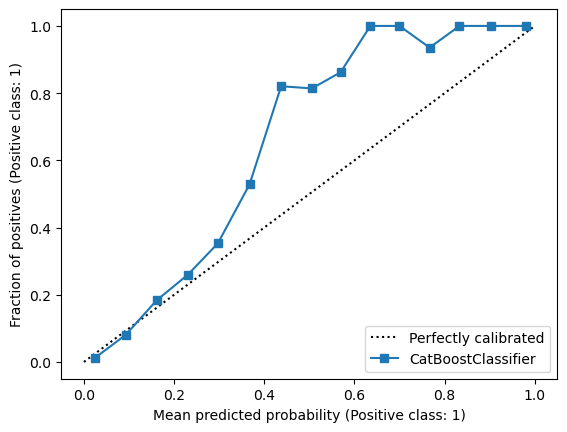

In [12]:
from sklearn.calibration import CalibrationDisplay, calibration_curve
CalibrationDisplay.from_estimator(model, Xtr.loc[~is_valid, cols], ytr[~is_valid], n_bins=15)

Калибровочная кривая и показатель precision демонстрируют плохую детекцию моделью положительного класса, модель ошибочно относит многие объекты к положительному классу.

#### __3. Итоговая модель__

In [14]:
#Feature engineering для итоговой модели
def features(ev, meta):
    g = ev.groupby('cookie_id')
    ev["hour"] = ev["event_ts"].dt.hour
    ev["dow"] = ev["event_ts"].dt.dayofweek
    ev["minute_of_day"] = (
        ev["event_ts"].dt.hour * 60 +
        ev["event_ts"].dt.minute
    )
    ev['platform'] = ev['platform'].str.lower()
    f = pd.DataFrame()
    f['n_events']= g.size()
    f["n_unique_eid"]= g["eid"].nunique()
    f["n_items"]= g["item_id"].nunique()
    f['n_categories'] = g['item_category'].nunique()
    f['n_unique_categories']= g["item_category"].nunique()
    f["eid_per_event"]= f["n_unique_eid"] / f["n_events"]
    f["items_per_event"] = f["n_items"] / f["n_events"]
    f["events_per_sec"] = g["event_ts"].apply(lambda s: len(s) / max((s.max() - s.min()).total_seconds(), 1))
    f["n_platforms"] = g["platform"].nunique()
    f["n_locations"] = g["item_location"].nunique()
    f["search_page_mean"] = g["search_page"].mean()
    f["pointer_x_std"] = g["pointer_x"].std()
    f["pointer_x_mean"] = g["pointer_x"].mean()
    f["pointer_y_std"] = g["pointer_y"].std()
    f["pointer_y_mean"] = g["pointer_y"].mean()
    f["n_pointer_x"] = g["pointer_x"].count()
    f["n_pointer_y"] = g["pointer_y"].count()
    f["first_event_ts"] = g["event_ts"].min()
    f["last_event_ts"] = g["event_ts"].max()
    f["n_queries"] = g["search_query"].nunique()
    f["n_seller_types"] = g["seller_type"].nunique()
    
    f = meta[['cookie_id', 'window_start_ts', 'cookie_created_at', 'window_end_ts']].merge(f.reset_index(), on='cookie_id', how='left')
    f["cookie_age_sec"] = (f["window_start_ts"] - f["cookie_created_at"]).dt.total_seconds()
    f["window_duration_sec"] = (f["window_end_ts"] - f["window_start_ts"]).dt.total_seconds()
    f["active_duration_sec"] = (f["last_event_ts"] - f["first_event_ts"]).dt.total_seconds()
    f["active_duration_min"] = (f["active_duration_sec"] / 60)
    ev["dt_sec"] = (
        ev.groupby("cookie_id")["event_ts"]
        .diff()
        .dt.total_seconds()
    )
    df_f = ev.groupby('cookie_id')['dt_sec'].agg(dt_mean="mean",
            dt_std="std",
            dt_median="median",
            dt_min="min",
            dt_max="max",
            dt_p10=lambda x: x.quantile(0.10),
            dt_p25=lambda x: x.quantile(0.25),
            dt_p75=lambda x: x.quantile(0.75),
            dt_p90=lambda x: x.quantile(0.90),)
    f = f.merge(df_f, on="cookie_id", how="left")
    for threshold in [1, 3, 5, 10, 30, 60]:
        col = f"dt_le_{threshold}s"

        tmp = (
            ev.assign(flag=(ev["dt_sec"] <= threshold).astype("int8"))
            .groupby("cookie_id")["flag"]
            .sum()
            .rename(col)
        )

        f = f.merge(
            tmp,
            on="cookie_id",
            how="left"
        )
    active_minutes = f["active_duration_min"].clip(lower=1 / 60)
    f["events_per_active_min"] = (f["n_events"] / active_minutes)
    f["items_per_active_min"] = (f["n_items"] / active_minutes)
    f["queries_per_active_min"] = (f["n_queries"] / active_minutes)

    def safe_div(a, b):
        a = pd.to_numeric(a, errors="coerce").astype("float64")
        b = pd.to_numeric(b, errors="coerce").astype("float64")

        b = b.replace(0, np.nan)

        return a / b

    f["events_per_item"] = safe_div(f["n_events"], f["n_items"])
    f["events_per_category"] = safe_div(f["n_events"], f["n_categories"])
    f["events_per_query"] = safe_div(f["n_events"], f["n_queries"])
    f["items_per_query"] = safe_div(f["n_items"], f["n_queries"])
    f["items_per_location"] = safe_div([f"n_items"], f["n_locations"])
    f["items_per_seller"] = safe_div(f["n_items"],f["n_seller_types"])
    event_counts = pd.crosstab(ev["cookie_id"], ev["event_name"])
    event_counts.columns = [f"event__{str(c)}" for c in event_counts.columns]
    event_counts = event_counts.reset_index()
    f = f.merge(event_counts, on="cookie_id", how="left")
    platform_counts = pd.crosstab(ev["cookie_id"], ev["platform"])
    platform_counts.columns = [f"platform__{str(c)}" for c in platform_counts.columns]
    f = f.merge(platform_counts.reset_index(), on="cookie_id",how="left")
    seller_counts = pd.crosstab(ev["cookie_id"], ev["seller_type"])
    seller_counts.columns = [f"seller__{str(c)}" for c in seller_counts.columns]
    f = f.merge(seller_counts.reset_index(), on="cookie_id", how="left")
    page_feat = (ev.groupby("cookie_id")["search_page"].agg(page_nunique="nunique", page_mean="mean",
                page_std="std",
                page_max="max",
                page_min="min",
            )
            .reset_index()
        )
    f = f.merge(
        page_feat,
        on="cookie_id",
        how="left"
    )
    item_stats = (
            ev.dropna(subset=["item_id"])
            .groupby("cookie_id")["item_id"]
            .agg(
                item_events="size",
                item_unique="nunique",
            )
            .reset_index()
        )

    item_stats["item_repeat_rate"] = (
        1 -
        item_stats["item_unique"] /
        item_stats["item_events"].replace(0, np.nan)
    )

    f = f.merge(
        item_stats,
        on="cookie_id",
        how="left"
    )
    query_stats = (
            ev.dropna(subset=["search_query"])
            .groupby("cookie_id")["search_query"]
            .agg(
                query_events="size",
                query_unique="nunique",
            )
            .reset_index()
        )

    query_stats["query_repeat_rate"] = (
        1 -
        query_stats["query_unique"] /
        query_stats["query_events"].replace(0, np.nan)
    )
    event_cols = [c for c in f.columns if c.startswith("event__")]

    for col in event_cols:
        f[col + "_rate"] = (
            f[col] /
            f["n_events"].replace(0, np.nan)
        )

    f = f.merge(
        query_stats,
        on="cookie_id",
        how="left"
    )
    ev = ev.sort_values(["cookie_id", "event_ts"])

    ev["dx"] = (
        ev.groupby("cookie_id")["pointer_x"]
        .diff()
    )

    ev["dy"] = (
        ev.groupby("cookie_id")["pointer_y"]
        .diff()
    )

    ev["move_distance"] = np.sqrt(
        ev["dx"] ** 2 +
        ev["dy"] ** 2
    )

    cursor_feat = (
        ev.groupby("cookie_id")
        .agg(
            cursor_moves=("move_distance", "count"),
            cursor_distance_mean=("move_distance", "mean"),
            cursor_distance_median=("move_distance", "median"),
            cursor_distance_std=("move_distance", "std"),
            cursor_distance_max=("move_distance", "max"),
        )
        .reset_index()
    )
    zero_move = (
            ev.assign(
                zero_move=(
                    ev["move_distance"].fillna(0) < 2
                ).astype("int8")
            )
            .groupby("cookie_id")["zero_move"]
            .mean()
            .rename("zero_move_rate")
            .reset_index()
        )

    f = f.merge(
        cursor_feat,
        on="cookie_id",
        how="left"
    )

    f = f.merge(
        zero_move,
        on="cookie_id",
        how="left"
    )
    hour_stats = (
        ev.groupby("cookie_id")["hour"]
        .agg(
            active_hours="nunique",
            hour_mean="mean",
            hour_std="std",
        )
        .reset_index()
    )

    f = f.merge(
        hour_stats,
        on="cookie_id",
        how="left"
    )
    ev["minute_bucket"] = ev["event_ts"].dt.floor("min")

    per_minute = (
        ev.groupby(["cookie_id", "minute_bucket"])
        .size()
        .rename("events_per_minute")
        .reset_index()
    )

    burst = (
        per_minute.groupby("cookie_id")["events_per_minute"]
        .agg(
            max_events_per_minute="max",
            mean_events_per_active_minute="mean",
            std_events_per_active_minute="std",
            p90_events_per_minute=lambda x: x.quantile(0.90),
            p99_events_per_minute=lambda x: x.quantile(0.99),
        )
        .reset_index()
    )

    f = f.merge(
        burst,
        on="cookie_id",
        how="left"
    )
    return f.fillna(0)


In [15]:
Xtr = features(ev_tr, train)
Xte = features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,window_start_ts,cookie_created_at,window_end_ts,n_events,n_unique_eid,n_items,n_categories,n_unique_categories,eid_per_event,...,cursor_distance_max,zero_move_rate,active_hours,hour_mean,hour_std,max_events_per_minute,mean_events_per_active_minute,std_events_per_active_minute,p90_events_per_minute,p99_events_per_minute
0,ck_54a059eb7d3ea68b,2026-04-06,2025-11-21 09:30:41,2026-04-07,7,3,4,3,3,0.428571,...,0.000000,1.000000,1,1.000000,0.000000,2,1.750000,0.500000,2.0,2.0
1,ck_7e4de46eeab82974,2026-04-06,2025-09-23 10:10:24,2026-04-07,41,7,19,1,1,0.170732,...,1762.325736,0.170732,8,14.829268,4.024316,3,1.366667,0.668675,2.1,3.0
2,ck_9320229ef6304522,2026-04-06,2026-03-04 00:08:02,2026-04-07,36,9,19,7,7,0.250000,...,1790.046089,0.083333,7,5.777778,3.906852,4,1.714286,0.902378,3.0,3.8
3,ck_30ccd25bc1714ed9,2026-04-06,2026-04-05 10:52:40,2026-04-07,21,5,10,1,1,0.238095,...,0.000000,1.000000,3,4.666667,2.373464,2,1.312500,0.478714,2.0,2.0
4,ck_a77c5f05948cdeef,2026-04-06,2026-01-01 03:54:35,2026-04-07,29,6,16,4,4,0.206897,...,1239.108147,0.137931,5,11.137931,1.597412,2,1.160000,0.374166,2.0,2.0


In [16]:
FEATURES = [
    "n_events",
    "n_unique_eid",
    "n_items",
    "n_categories",
    "n_unique_categories",
    "eid_per_event",
    "items_per_event",
    "events_per_sec",

    "cookie_age_sec",
    "window_duration_sec",
    "active_duration_sec",
    "active_duration_min",
    "events_per_active_min",
    "items_per_active_min",
    "queries_per_active_min",

    "dt_mean",
    "dt_std",
    "dt_median",
    "dt_min",
    "dt_max",
    "dt_p10",
    "dt_p25",
    "dt_p75",
    "dt_p90",
    "dt_le_1s",
    "dt_le_3s",
    "dt_le_5s",
    "dt_le_10s",
    "dt_le_30s",
    "dt_le_60s",

    "event__contact_chat_open",
    "event__contact_message_sent",
    "event__contact_phone_show",
    "event__favorite_add",
    "event__item_view",
    "event__login",
    "event__photo_swipe",
    "event__search_results_view",
    "event__seller_page_view",

    "event__contact_chat_open_rate",
    "event__contact_message_sent_rate",
    "event__contact_phone_show_rate",
    "event__favorite_add_rate",
    "event__item_view_rate",
    "event__login_rate",
    "event__photo_swipe_rate",
    "event__search_results_view_rate",
    "event__seller_page_view_rate",

    "item_events",
    "item_unique",
    "item_repeat_rate",
    "query_events",
    "query_unique",
    "query_repeat_rate",

    "cursor_moves",
    "cursor_distance_mean",
    "cursor_distance_median",
    "cursor_distance_std",
    "cursor_distance_max",
    "zero_move_rate",

    "pointer_x_std",
    "pointer_y_std",
    "pointer_x_mean",
    "pointer_y_mean",
    "n_pointer_x",
    "n_pointer_y",

    "page_nunique",
    "page_mean",
    "page_std",
    "page_max",
    "page_min",

    "n_platforms",
    "n_locations",
    "n_queries",
    "n_seller_types",

    "max_events_per_minute",
    "mean_events_per_active_minute",
    "std_events_per_active_minute",
    "p90_events_per_minute",
    "p99_events_per_minute",
    "events_per_item",
    "events_per_category",
    "events_per_query",
    "items_per_query",
    "items_per_location",
    "items_per_seller",


    "platform__android",
    "platform__desktop",
    "platform__ios",
    "platform__iphone",
    "platform__web",

    "seller__private",
    "seller__pro",

    "search_page_mean",
]

__Итоговая модель:__

In [62]:
Model = CatBoostClassifier(iterations = 3000, learning_rate = 0.05, depth = 5, l2_leaf_reg=1,
        od_wait = 50,
        use_best_model =  True,
        verbose = False,
        random_seed = 42,
        )
Model.fit(
        Xtr.loc[~is_valid, FEATURES],
        ytr[~is_valid],
        verbose=False,
        eval_set = (Xtr.loc[is_valid, FEATURES], ytr[is_valid])
    )
p_va = Model.predict_proba(Xtr.loc[is_valid, FEATURES])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr[is_valid], p_va), 4))
print('доля ботов (это уровень константы):', round(ytr[is_valid].mean(), 4))

P@R0.7 на валидации: 0.7467
доля ботов (это уровень константы): 0.082


In [64]:
sub = pd.DataFrame({
    'cookie_id': Xte.cookie_id,
    'score': Model.predict_proba(Xte[FEATURES])[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.000546
1,ck_a76ee3b3e3e522fd,0.129585
2,ck_94c9a4d382689e82,0.080406
3,ck_8eaf9509ad9462a0,0.001431
4,ck_9a88a5a989cb5bc6,0.018409


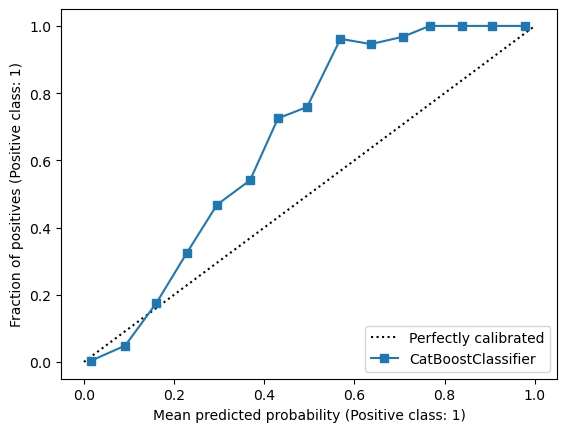

In [65]:
CalibrationDisplay.from_estimator(Model, Xtr.loc[~is_valid, FEATURES], ytr[~is_valid], n_bins=15)

Метрики и калибровочная кривая демонстрируют существенное улучшение, хотя у модели всё ещё высокий уровень ошибки FP.